# Main usage

This notebook walks through a complete **customics** workflow on a demo dataset.


In [4]:
import customics
from customics import CustOMICS

## Data preparation

### Data loading

`customics` is built on top of [`mudata.MuData`](https://mudata.readthedocs.io/stable/), which is a convenient data structure for multimodal objects.

For the sake of this tutorial, you can load a toy dataset with [`toy_dataset`][customics.toy_dataset]:

In [5]:
mdata = customics.toy_dataset()

/Users/alihamraoui/projects/tests/CustOmics/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


As shown below, we have 100 patients across 3 modalities:

1. RNA-seq gene expression
2. Reverse Phase Protein Array (RPPA)
3. DNA methylation


In [6]:
mdata

MuData object with n_obs × n_vars = 100 × 658
  obs:	'subjects', 'cluster.id', 'OS', 'OS.time'
  3 modalities
    rna:	100 × 131
    protein:	100 × 160
    methyl:	100 × 367

For instance, we can access the protein modality as below.

> Note that `mdata["protein"]` is an [`AnnData`](https://anndata.readthedocs.io/en/latest/) object.


In [7]:
mdata["protein"].to_df().head()

probe,ACC1,ACC_pS79,ACVRL1,Akt_pS473,PRAS40_pT246,Annexin.1,AR,A.Raf_pS299,ASNS,ATM,...,XBP1,XRCC1,Ku80,YAP,YAP_pS127,YB.1,YB.1_pS102,14.3.3_beta,14.3.3_epsilon,14.3.3_zeta
subject1,-0.528421,-0.826949,2.465380,0.118108,2.682673,-0.473918,2.692947,0.392130,-1.458304,-0.518608,...,2.365702,-0.115504,2.125662,0.198529,0.263075,2.035369,3.276020,-0.164232,2.240264,0.390613
subject2,-0.804377,-0.858630,2.679618,1.163897,2.789568,0.326823,3.703054,-0.207030,-0.567368,-1.447359,...,2.369684,-0.250648,2.028639,0.294427,0.087710,2.748533,2.655492,-0.020322,2.584052,1.083867
subject3,0.596001,0.175652,2.782368,-1.550062,2.136330,-0.729363,3.987616,-0.065740,0.225819,0.321197,...,2.912468,0.235292,3.102378,0.717648,0.118142,2.608048,1.894032,0.423970,2.470960,0.355451
subject4,2.306769,2.387911,2.152993,0.175379,-0.243862,0.206090,3.851968,-0.347185,1.595250,2.998184,...,0.019668,2.319597,0.211079,0.178415,0.312633,-0.205992,0.151597,2.289823,0.153826,-0.634842
subject5,-0.948945,-0.640623,2.242055,0.829983,2.732090,-0.218177,2.376110,-0.510938,-1.030711,-0.125802,...,2.169958,-0.044484,2.905596,0.539468,0.338059,2.257715,2.718098,-0.190475,2.523407,0.445861


### Register clinical columns

`mdata.obs` is a DataFrame whose index are sample IDs, and contains the following columns:

- an event-indicator (`OS`, 0 = censored, 1 = event)
- a survival-time column (`OS.time`, in days).
- **tumour subtype label** (`cluster.id`, classes 1–5)


In [8]:
mdata.obs.head()

,subjects,cluster.id,OS,OS.time
subject1,1,5,0,2531
subject2,2,5,1,759
subject3,3,5,1,2453
subject4,4,3,0,220
subject5,5,5,0,2431


We store these column names using the [`prepare_input`][customics.prepare_input] function.

> This avoids to pass these parameters to all the downstream functions.

In [9]:
customics.prepare_input(mdata, label="cluster.id", event="OS", surv_time="OS.time")

### Quick exploration

[`plot_cohort_overview`][customics.plot_cohort_overview] gives a quick look at the subtype distribution and survival times.

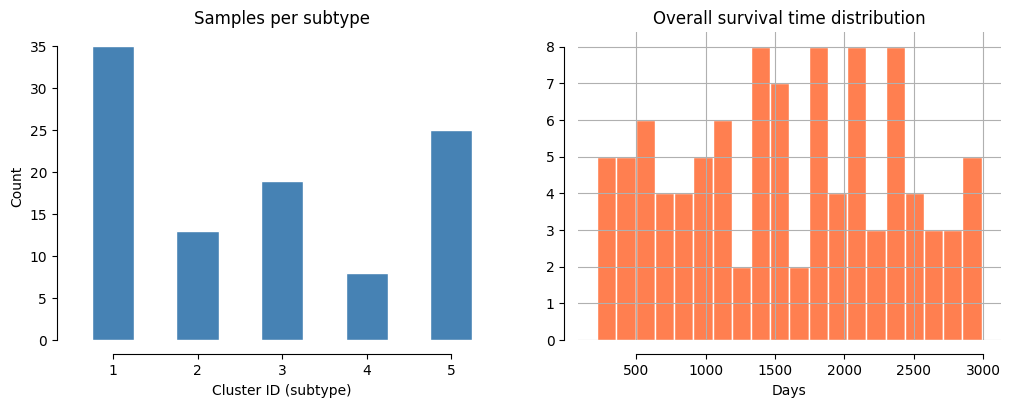

In [10]:
customics.plot_cohort_overview(mdata)

### Splitting the data


Below, we extract the IDs of the samples shared across all modalities with [`get_shared_samples`][customics.get_shared_samples], and we split the full cohort into **train / validation / test** `MuData` objects with [`split_mudata`][customics.split_mudata].

In [11]:
shared_samples = customics.get_shared_samples(mdata)

mdata_train, mdata_val, mdata_test = customics.split_mudata(mdata)

/Users/alihamraoui/projects/tests/CustOmics/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/alihamraoui/projects/tests/CustOmics/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/alihamraoui/projects/tests/CustOmics/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


## Model configuration

[`CustOMICS`][customics.CustOMICS.__init__] is configured through five parameter dictionaries. Each controls one component of the architecture.

See more details on hyperparameter tuning on [this tutorial](hyperparameter_tuning.md).

In [12]:
source_params = {
    source: {
        "input_dim": adata.n_vars,  # auto-filled — do not hardcode
        "hidden_dim": [256, 128],
        "latent_dim": 64,
        "norm": True,
        "dropout": 0.2,
    }
    for source, adata in mdata.mod.items()
}

central_params = {
    "hidden_dim": [256, 128],
    "latent_dim": 64,  # dimension of the shared latent code z
    "norm": True,
    "dropout": 0.2,
    "beta": 1.0,  # MMD regularisation weight
}

classif_params = {
    "n_class": 5,  # subtypes 1-5
    "lambda": 5.0,  # classification loss weight
    "hidden_layers": [64, 32],
    "dropout": 0.2,
}

surv_params = {
    "lambda": 0.0,
    "dims": [32, 16],
    "activation": "SELU",
    "l2_reg": 1e-2,
    "norm": True,
    "dropout": 0.2,
}

train_params = {"switch": 15, "lr": 1e-3}

## Model training

### Model instantiation

Pass the five config dicts to [`CustOMICS`][customics.CustOMICS.__init__]. The model is built immediately but
weights are random until [`fit`][customics.CustOMICS.fit] is called.

In [13]:
model = CustOMICS(
    source_params=source_params,
    central_params=central_params,
    classif_params=classif_params,
    surv_params=surv_params,
    train_params=train_params,
)

[INFO] (customics.model) Using cpu by default.


Then, we [`fit`][customics.CustOMICS.fit] the model. Here, 30 epochs is enough for the 100-sample toy dataset.

In [14]:
model.fit(mdata=mdata_train, omics_val=mdata_val, n_epochs=30)

[INFO] (customics.model) Epoch 1/30 | train=28.3510 | val=31.1127
[INFO] (customics.model) Epoch 2/30 | train=24.1300 | val=27.2528
[INFO] (customics.model) Epoch 3/30 | train=18.8413 | val=23.2119
[INFO] (customics.model) Epoch 4/30 | train=18.1666 | val=19.2596
[INFO] (customics.model) Epoch 5/30 | train=15.9653 | val=15.0313
[INFO] (customics.model) Epoch 6/30 | train=15.6716 | val=13.5321
[INFO] (customics.model) Epoch 7/30 | train=14.6013 | val=12.3413
[INFO] (customics.model) Epoch 8/30 | train=11.1737 | val=12.8830
[INFO] (customics.model) Epoch 9/30 | train=12.7438 | val=10.9623
[INFO] (customics.model) Epoch 10/30 | train=13.4023 | val=10.7329
[INFO] (customics.model) Epoch 11/30 | train=9.2252 | val=10.8890
[INFO] (customics.model) Epoch 12/30 | train=8.1664 | val=10.7212
[INFO] (customics.model) Epoch 13/30 | train=9.6589 | val=10.0334
[INFO] (customics.model) Epoch 14/30 | train=7.6694 | val=9.2598
[INFO] (customics.model) Epoch 15/30 | train=6.7208 | val=9.3922
[INFO] (cus

[`plot_loss`][customics.CustOMICS.plot_loss] plots the train/validation loss curves to check for overfitting.
The vertical dashed line marks the phase 1 to phase 2 transition.

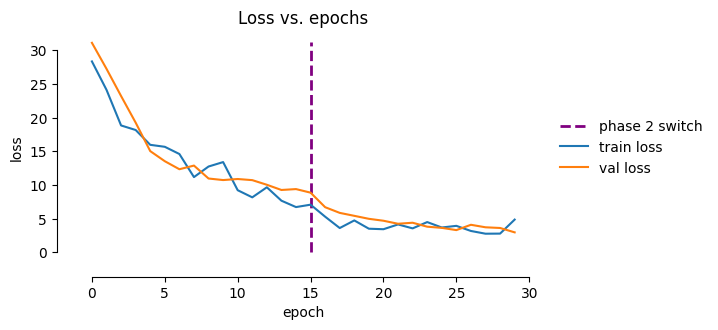

In [15]:
model.plot_loss()

## Model evaluation

[`evaluate`][customics.CustOMICS.evaluate] runs inference on the held-out **test set** and returns a metrics dict.

- **Classification** (`task="classification"`): accuracy, macro F1, weighted F1,
  and per-class ROC-AUC.
- **Survival** (`task="survival"`): concordance index (C-index) via the Cox head.

> Set `plot_roc=True` to overlay per-class ROC curves on a single figure.

{'Accuracy': 1.0, 'F1-score': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'AUC': 1.0}

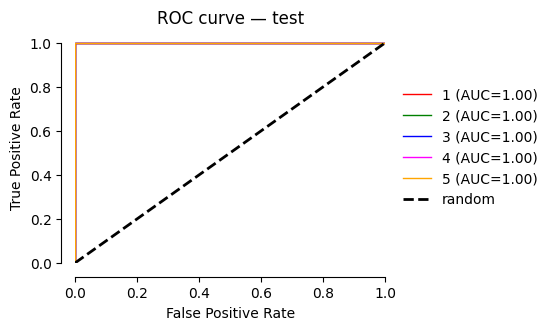

In [16]:
metrics = model.evaluate(mdata=mdata_test, task="classification", batch_size=1024, plot_roc=True)

metrics

Now, we can evaluate the Cox survival head on the test split.

> With synthetic OS/OS.time the C-index will be ~0.5 (random), which is expected. Replace OS/OS.time with real data to obtain meaningful survival performance.


In [17]:
surv_metrics = model.evaluate(mdata=mdata_test, task="survival", batch_size=1024)

print("C-index :", surv_metrics)

C-index : 0.7021276595744681


## Latent space

[`get_latent_representation`][customics.CustOMICS.get_latent_representation] encodes every sample in `mdata` through the
trained central VAE and returns a NumPy array of shape `(n_samples, latent_dim)`.

[`plot_representation`][customics.CustOMICS.plot_representation] runs UMAP on that array and colours each point by the
clinical label, a quick sanity check that the model has learned subtype-discriminative features. By default, it uses the provided label.

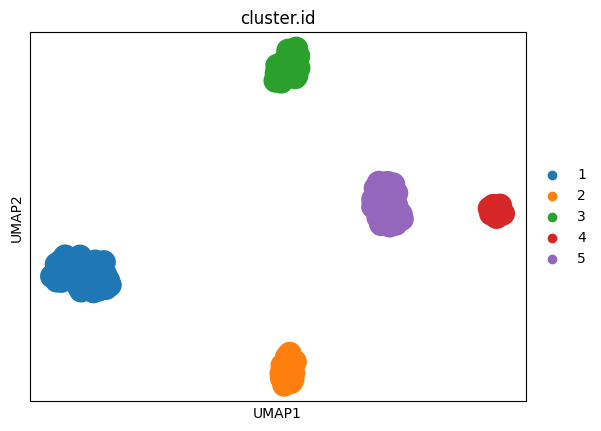

In [18]:
model.plot_representation(mdata=mdata)

## Survival risk stratification

[`stratify`][customics.CustOMICS.stratify] uses the Cox head to assign each sample a risk score, then splits
the cohort into high-risk / low-risk groups at the median score and draws a
Kaplan-Meier curve.

> **Note:** with synthetic survival data the curves will overlap.
> This section shows the API; meaningful separation requires real OS/OS.time.

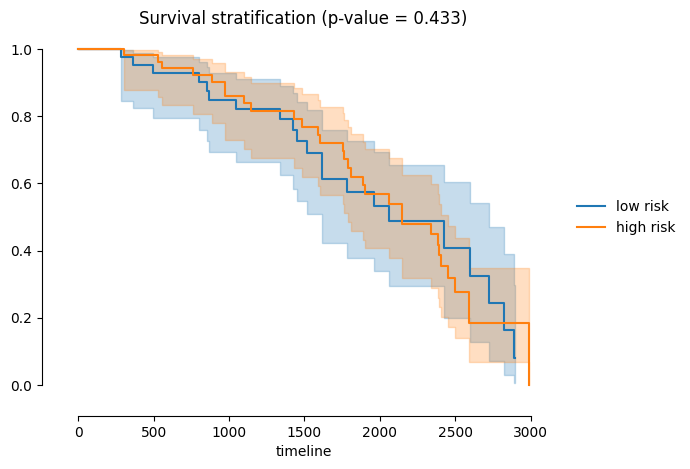

In [19]:
model.stratify(mdata=mdata)

## Feature importance

[`explain`][customics.CustOMICS.explain] uses `shap.DeepExplainer` to compute feature-attribution values for
one omics source and one tumour subtype.

The bar plot shows the **mean absolute SHAP value** for each feature — higher
means more influential for predicting the chosen subtype.

First, we show the feature importance for RNA expression, subtype 1:

[INFO] (customics.model) Using cpu by default.


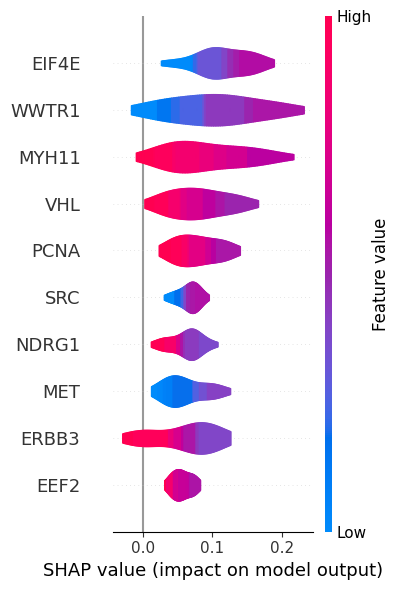

In [20]:
model.explain(sample_ids=shared_samples, mdata=mdata, source="rna", subtype="1")

Feature importance for protein expression, subtype 1


[INFO] (customics.model) Using cpu by default.


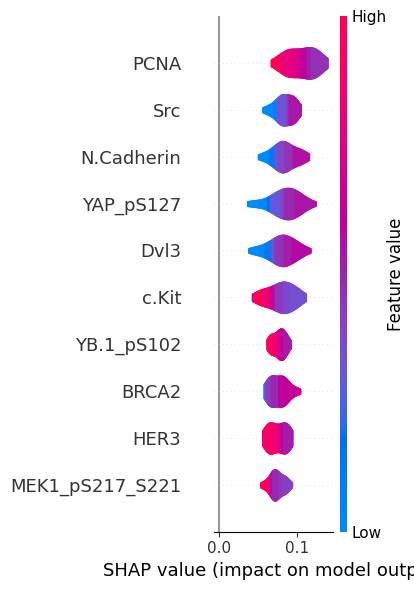

In [21]:
model.explain(sample_ids=shared_samples, mdata=mdata, source="protein", subtype="1")

Feature importance for DNA methylation, subtype 1


[INFO] (customics.model) Using cpu by default.


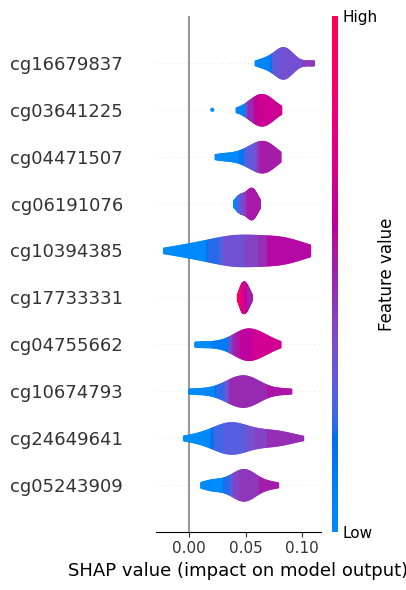

In [22]:
model.explain(sample_ids=shared_samples, mdata=mdata, source="methyl", subtype="1")

## Saving the model

You can save the model with [`save`][customics.CustOMICS.save] and load it back later via [`load`][customics.CustOMICS.load]:

In [23]:
model.save("customics_model.pt")

loaded_model = CustOMICS.load("customics_model.pt")

[INFO] (customics.model) Model saved to customics_model.pt
[INFO] (customics.model) Using cpu by default.
[INFO] (customics.model) Model loaded from customics_model.pt


Sanity-check: predictions from the reloaded model should match the originals.


In [24]:
metrics_reloaded = loaded_model.evaluate(mdata=mdata_test, task="classification", batch_size=1024, plot_roc=False)

metrics_reloaded

{'Accuracy': 1.0, 'F1-score': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'AUC': 1.0}